In [1]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from textblob import TextBlob
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from keras.utils import to_categorical
import numpy as np
import re
import pickle

2025-12-28 10:58:22.597166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766919502.784294      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766919502.837420      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
nltk_stopwords = "/kaggle/input/stopwords/stopwords"
nltk.data.path.append(nltk_stopwords)

nltk_wordnet = "/kaggle/input/wordnet/wordnet"
nltk.data.path.append(nltk_wordnet)

nltk_punkt = "/kaggle/input/punkt/punkt"
nltk.data.path.append(nltk_punkt)

In [3]:
DATA_DIR = "/kaggle/input/"
OUT_DIR = "/kaggle/working/"
data_path = f"{DATA_DIR}jigsaw-unintended-bias-in-toxicity-classification/all_data.csv" # Assuming you're using this dataset for toxic comments
glove_path = f"{DATA_DIR}glove840b300dtxt/glove.840B.300d.txt" # Common GloVe dataset on Kaggle

In [4]:
# Output paths for saving tokenizer and model
tokenizer_filename = f'{OUT_DIR}ethics_and_bias_tokenizer.pkl'
model_filename = f"{OUT_DIR}ethical_and_bias_model.keras"

In [5]:
# Preprocessing functions
def preprocess_text(text):
    # Check if text is a string, and convert if necessary
    if not isinstance(text, str):
        try:
            # Attempt conversion to string, assuming it's a number
            text = str(text)
        except ValueError:
            # If conversion fails (e.g., non-numeric value), handle it appropriately
            # (e.g., log a warning, replace with an empty string, etc.)
            # Here, we'll replace with an empty string
            text = ""
            print(f"Warning: Encountered non-convertible data in preprocess_text: {text}")

    # Preprocessing steps
    text = text.lower() # Lowercase
    text = re.sub(r"http\S+", "", text) # Remove URLs
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text) # Remove punctuation
    stop_words = stopwords.words('english')
    text = [word for word in text.split() if word not in stop_words] # Remove stopwords
    lemmatizer = WordNetLemmatizer()
    text = [lemmatizer.lemmatize(word) for word in text] # Lemmatization
    return " ".join(text)

In [6]:
def prepare_data(data):
    data['comment_text'] = data['comment_text'].apply(preprocess_text)

    # Calculate sentiment score using TextBlob
    def calculate_sentiment(text):
        try:
            sentiments = [TextBlob(word).sentiment.polarity for word in text.split()]
            if len(sentiments) == 0:
                return 0  # or any other default value
            return np.mean(sentiments)
        except Exception as e:  # Handle exceptions for robustness
            print(f"Error processing text: {text}\n{e}")
            return 0  # or handle the error in a more appropriate way

    data['sentiment_score'] = data['comment_text'].apply(calculate_sentiment)

    # Assign sentiment based on specific emotions and sentiment score
    sentiment_thresholds = {
        'positive': (0.5, 1),
        'negative': (-1, -0.5),
        'neutral': (-0.5, 0.5),
        'toxic': None  # You might consider adding thresholds for toxicity
    }

    def assign_sentiment(row):
        for sentiment, thresholds in sentiment_thresholds.items():
            if thresholds is not None and thresholds[0] <= row['sentiment_score'] <= thresholds[1]:
                return sentiment
        return 'neutral'  # Default to neutral if no condition matches

    data['sentiment'] = data.apply(assign_sentiment, axis=1)

    # Tokenization and padding
    tokenizer = Tokenizer(num_words=5000)
    tokenizer.fit_on_texts(data['comment_text'])
    X_seq = tokenizer.texts_to_sequences(data['comment_text'])
    X_pad = pad_sequences(X_seq, maxlen=200)

    # Class labels
    class_labels = ['neutral', 'positive', 'negative', 'toxic']

    # Convert class labels to numerical values
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(data['sentiment'])
    y = to_categorical(y_encoded, num_classes=len(class_labels))

    return X_pad, y, class_labels, tokenizer

In [7]:
data = pd.read_csv(data_path)

In [8]:
X_pad,y,class_labels,tokenizer = prepare_data(data)

In [9]:
# Save the Tokenizer
with open(tokenizer_filename, 'wb') as f:
  pickle.dump(tokenizer, f)
print(f"Tokenizer saved to {tokenizer_filename}")

Tokenizer saved to /kaggle/working/ethics_and_bias_tokenizer.pkl


In [10]:
# Example with GloVe
embeddings_index = {}
# Open the GloVe data file
with open(glove_path, 'r', encoding='utf-8') as f:
  for line in f:
    # Split the line and remove leading/trailing whitespaces from each value
    values = line.strip().split()
    try:
      # Attempt to convert all values to floats
      coefs = np.asarray([float(v.strip()) for v in values[1:]], dtype='float32')
    except ValueError:
      # If conversion fails (unexpected text), skip the line
      continue
    word = values[0]
    embeddings_index[word] = coefs

embedding_matrix = np.zeros((5000, 300)) # Adjust dimensions as needed
for word, i in tokenizer.word_index.items():
    if i < 5000:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

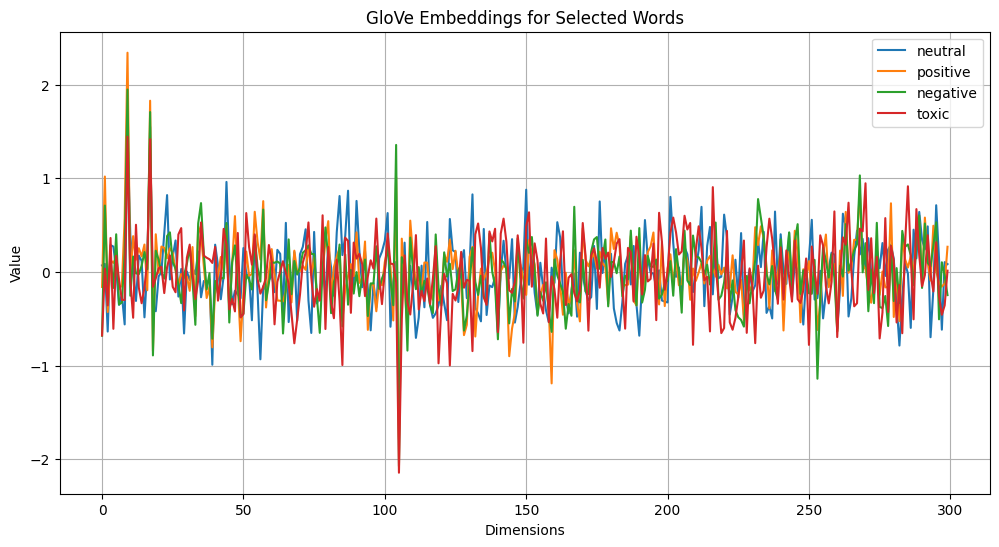

In [11]:
# Example code to visualize a few GloVe vectors
def plot_glove_embeddings(embeddings_index, words_to_plot, num_vectors=10):
    plt.figure(figsize=(12, 6))
    for i, word in enumerate(words_to_plot[:num_vectors]):
        if word in embeddings_index:
            vector = embeddings_index[word]
            plt.plot(vector, label=word)
    plt.title('GloVe Embeddings for Selected Words')
    plt.xlabel('Dimensions')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{OUT_DIR}glove_embeddings_plot.png')
    plt.show()

# Specify words to plot
words_to_plot = ['neutral','positive','negative','toxic']
plot_glove_embeddings(embeddings_index, words_to_plot)

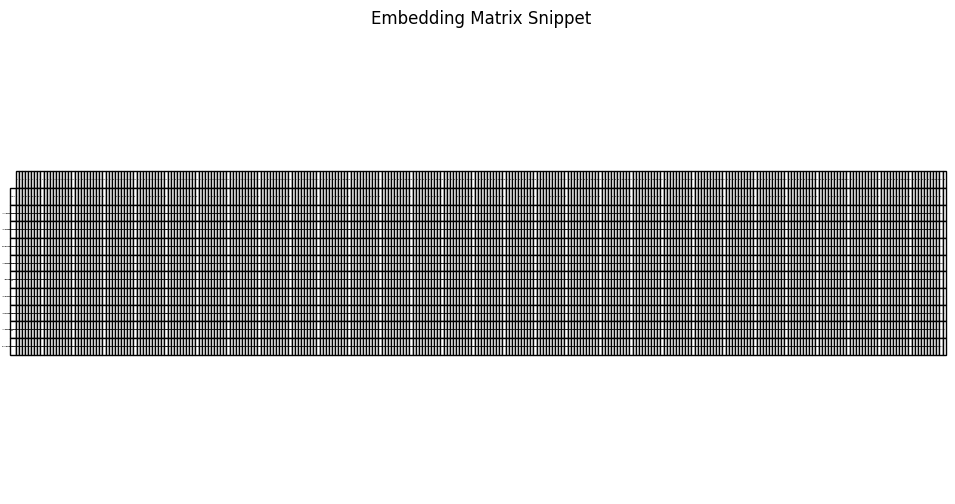

In [12]:
def plot_embedding_matrix(embedding_matrix, word_index, num_words=10):
    # Create a DataFrame for easy visualization
    matrix_df = pd.DataFrame(embedding_matrix[:num_words], index=[word for word, i in word_index.items() if i <= num_words])
    plt.figure(figsize=(12, 6))
    pd.plotting.table(plt.gca(), matrix_df, loc='center')
    plt.title('Embedding Matrix Snippet')
    plt.axis('off')
    plt.savefig(f'{OUT_DIR}embedding_matrix_plot.png')
    plt.show()

plot_embedding_matrix(embedding_matrix, tokenizer.word_index)

In [13]:
# Train-test split - Check for overwrites and split configuration
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

In [14]:
model = Sequential()
model.add(Embedding(5000, 300, weights=[embedding_matrix], trainable=True))

# Add more LSTM layers
model.add(Bidirectional(LSTM(512, return_sequences=True)))
model.add(Bidirectional(LSTM(256, return_sequences=False)))

# Add dense layers with activation functions
model.add(Dense(128, activation='leaky_relu'))  # Hidden layer for feature extraction
model.add(Dense(64, activation='leaky_relu'))  # Another hidden layer for further processing

num_classes = len(class_labels) # Assuming class_labels contains all possible classes

# Output layer for multi-label, multi-class classification
model.add(Dense(num_classes, activation='softmax'))  # Use softmax for multi-label classification

I0000 00:00:1766925156.978783      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [15]:
# Compile model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [16]:
# Train model
history = model.fit(X_train, y_train, epochs=1 ,batch_size=1024, validation_split=0.2)

I0000 00:00:1766925167.016137     102 cuda_dnn.cc:529] Loaded cuDNN version 90300


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1992s 2s/step - accuracy: 0.9942 - loss: 0.0197 - val_accuracy: 0.9986 - val_loss: 0.0041


In [17]:
# Accuracy on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

12497/12497 ━━━━━━━━━━━━━━━━━━━━ 513s 41ms/step - accuracy: 0.9986 - loss: 0.0041
Test Accuracy: 0.9986
Test Loss: 0.0040


In [18]:
# Accuracy on train set
train_loss, train_acc = model.evaluate(X_train, y_train)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Train Loss: {train_loss:.4f}")

49988/49988 ━━━━━━━━━━━━━━━━━━━━ 2064s 41ms/step - accuracy: 0.9987 - loss: 0.0036
Train Accuracy: 0.9987
Train Loss: 0.0036


In [19]:
model.save(model_filename, save_format='keras')

In [20]:
from keras.utils import plot_model

# Assuming `model` is your Keras model
def save_model_summary(model, filename=f'{OUT_DIR}model_summary.png'):
    plot_model(model, to_file=filename, show_shapes=True, show_layer_names=True)
    print(f"Model summary saved as {filename}")

save_model_summary(model)

Model summary saved as /kaggle/working/model_summary.png


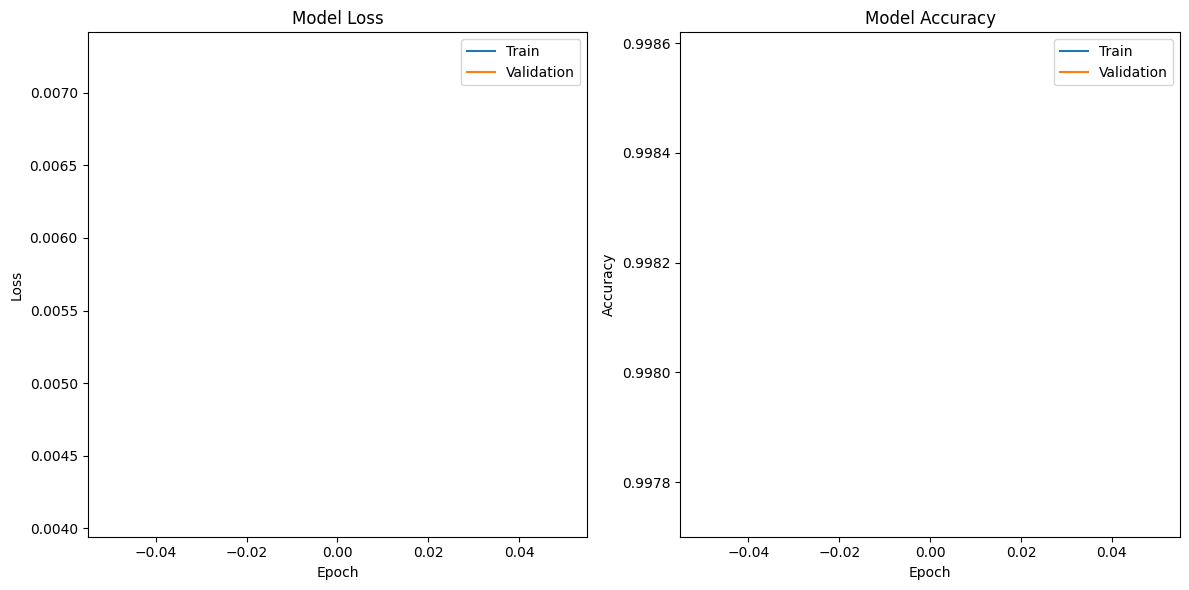

In [29]:
def plot_training_results(history):
    plt.figure(figsize=(12, 6))

    # Plot training & validation loss values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'])

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}training_results.png')
    plt.show()

plot_training_results(history)

In [23]:
y_pred_proba = model.predict(X_test)

y_pred = y_pred_proba.argmax(axis=1)

y_true_labels = y_test.argmax(axis=1)

y_pred_labels = y_pred_proba.argmax(axis=1)

12497/12497 ━━━━━━━━━━━━━━━━━━━━ 511s 41ms/step


Plot saved as my_model_results.png


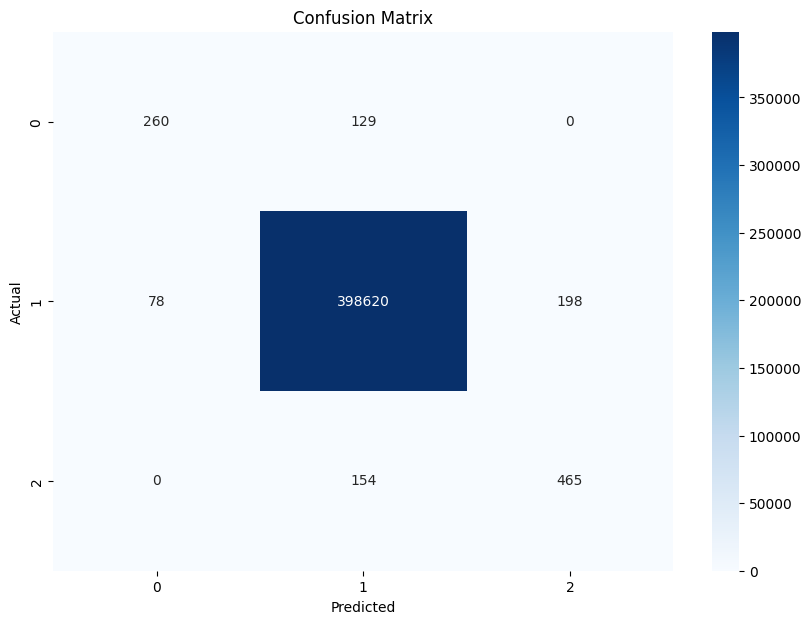

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

def save_confusion_matrix(y_true, y_pred, filename="confusion_matrix.png"):
    # Ensure inputs are class indices (integers)
    y_true_labels = np.argmax(y_true, axis=1) if len(y_true.shape) > 1 else y_true
    y_pred_labels = np.argmax(y_pred, axis=1) if len(y_pred.shape) > 1 else y_pred
    
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    
    # Save the file
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved as {filename}")
    
    plt.show()

# Usage
save_confusion_matrix(y_test, y_pred, "my_model_results.png")

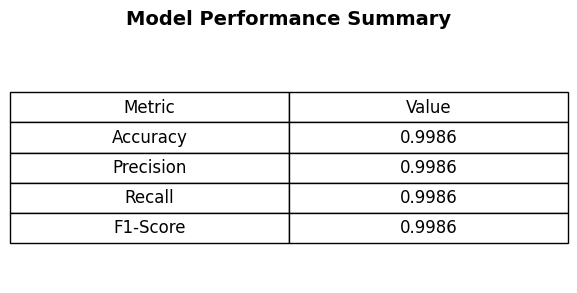

Metrics saved to performance_metrics.png


In [30]:
import matplotlib.pyplot as plt

def save_metrics_to_png(accuracy, precision, recall, f1, filename="performance_metrics.png"):
    # Data to display
    metrics = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
        'Value': [f"{accuracy:.4f}", f"{precision:.4f}", f"{recall:.4f}", f"{f1:.4f}"]
    }
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.axis('off')  # Hide the axes
    
    # Create the table
    table_data = [[k, v] for k, v in zip(metrics['Metric'], metrics['Value'])]
    table = ax.table(cellText=table_data, colLabels=['Metric', 'Value'], 
                     loc='center', cellLoc='center')
    
    # Styling the table
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.8) # Stretch the table cells for readability
    
    plt.title("Model Performance Summary", fontsize=14, fontweight='bold', pad=20)
    
    # Save the file
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Metrics saved to {filename}")

# Usage
save_metrics_to_png(accuracy, precision, recall, f1)